In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from dotenv import load_dotenv
from pymongo import MongoClient

In [2]:
load_dotenv()  # cerca .env nella cartella corrente o superiori

MONGO_URI = os.environ.get("MONGO_URI")
print(MONGO_URI is not None)  # deve stampare True

client = MongoClient(MONGO_URI)
df = pd.DataFrame(list(client["idealo_ram"]["dw_ram_products"].find({}, {"_id": 0})))
df.to_csv("dw_ram_products.csv", index=False)

True


# 04 - Confronto prezzi tra mercati (IT vs DE)

Genera le visualizzazioni per il confronto dei prezzi RAM tra Italia e Germania,
a partire dalla collection consolidata `dw_ram_products` (export CSV).

Output: 6 PNG in `../../Data/Viz/` (una cartella creata da questo notebook).

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

COL_IT = '#4C72B0'   # blu
COL_DE = '#DD8452'   # arancione

CSV_PATH = '../02_Data_viz/dw_ram_products.csv'   # adatta il path se necessario
OUT_DIR = '../02_Data_viz/Plots/'   # adatta il path se necessario
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Caricamento dati

In [4]:
df = pd.read_csv(CSV_PATH)
df['market_label'] = df['market'].map({'IT': 'Italia', 'DE': 'Germania'})

print(df.shape)
df.groupby(['market', 'ram_category']).size()

(656, 24)


market  ram_category
DE      DDR4            174
        DDR5            156
IT      DDR4            174
        DDR5            152
dtype: int64

## 2. Boxplot: distribuzione prezzi IT vs DE (per DDR4/DDR5)

Versione lineare + versione log scale (utile perché DDR5 ha outlier molto alti che schiacciano il grafico lineare).

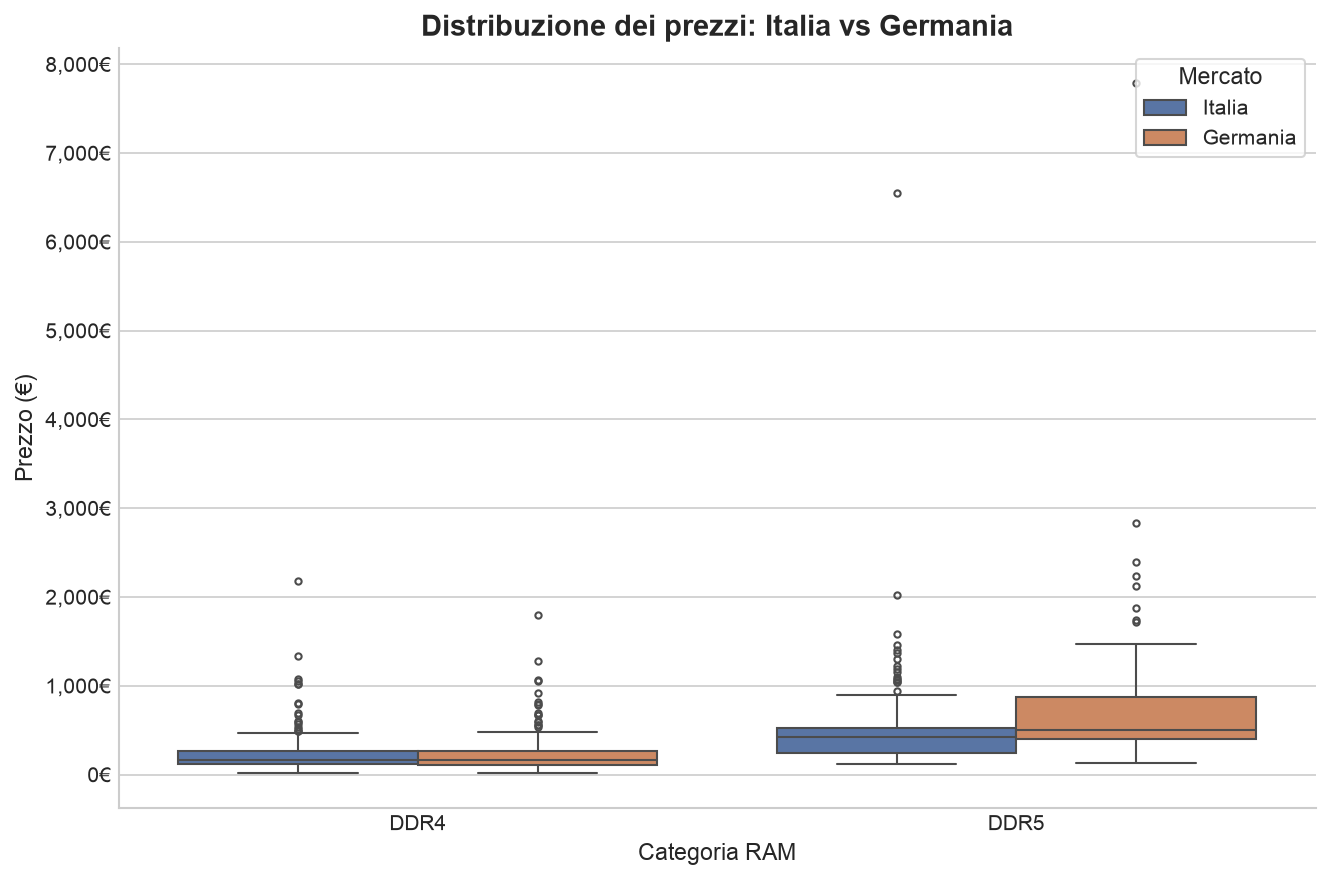

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=df, x='ram_category', y='rawPrice', hue='market_label',
    palette={'Italia': COL_IT, 'Germania': COL_DE},
    ax=ax, showfliers=True, fliersize=3
)
ax.set_title('Distribuzione dei prezzi: Italia vs Germania', fontweight='bold')
ax.set_xlabel('Categoria RAM')
ax.set_ylabel('Prezzo (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}€'))
ax.legend(title='Mercato', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/01_boxplot_prezzi_mercati.png', dpi=150, bbox_inches='tight')
plt.show()

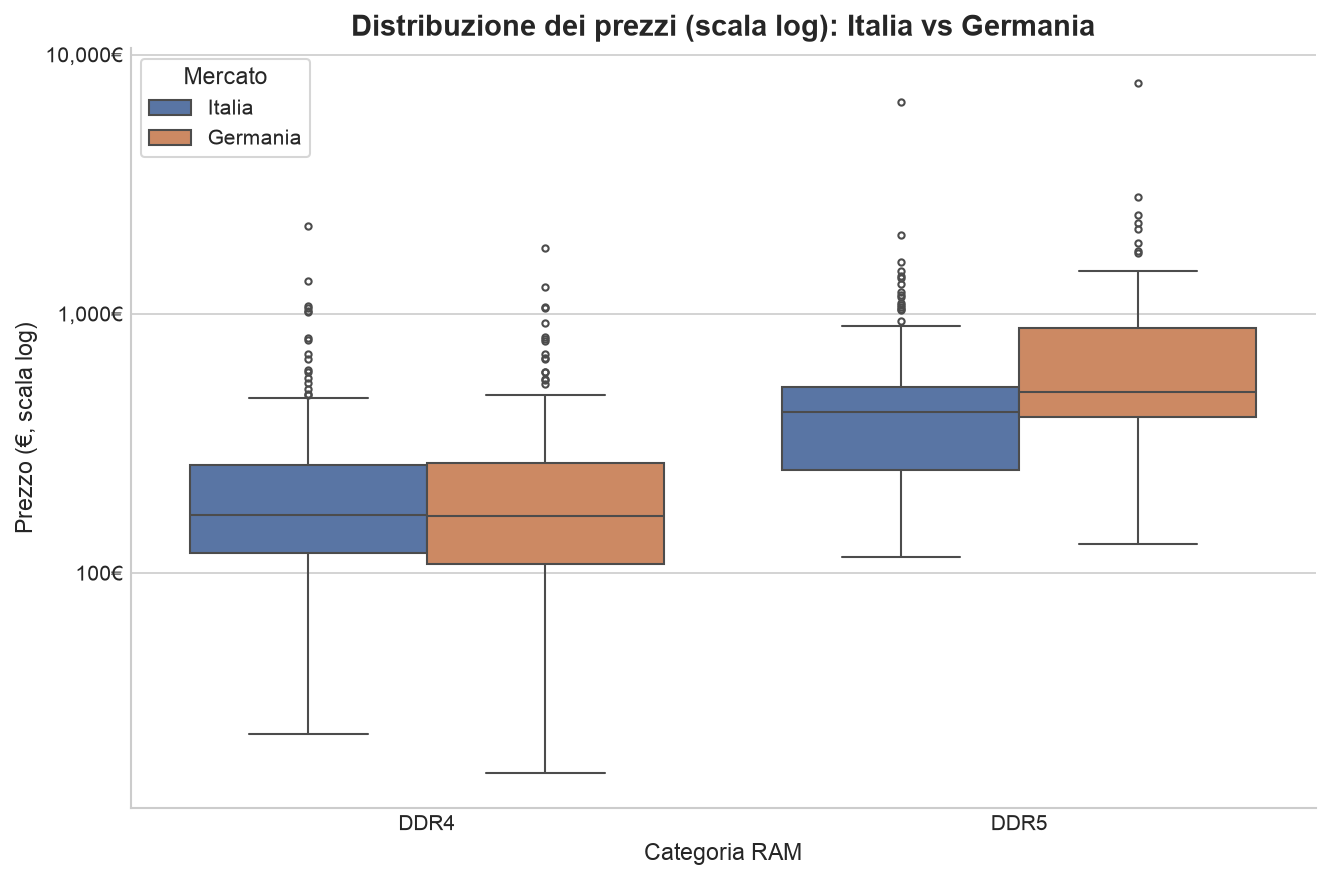

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=df, x='ram_category', y='rawPrice', hue='market_label',
    palette={'Italia': COL_IT, 'Germania': COL_DE},
    ax=ax, showfliers=True, fliersize=3
)
ax.set_yscale('log')
ax.set_title('Distribuzione dei prezzi (scala log): Italia vs Germania', fontweight='bold')
ax.set_xlabel('Categoria RAM')
ax.set_ylabel('Prezzo (€, scala log)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}€'))
ax.legend(title='Mercato', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/01b_boxplot_prezzi_mercati_log.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bar chart: prezzo medio e mediano per mercato x categoria

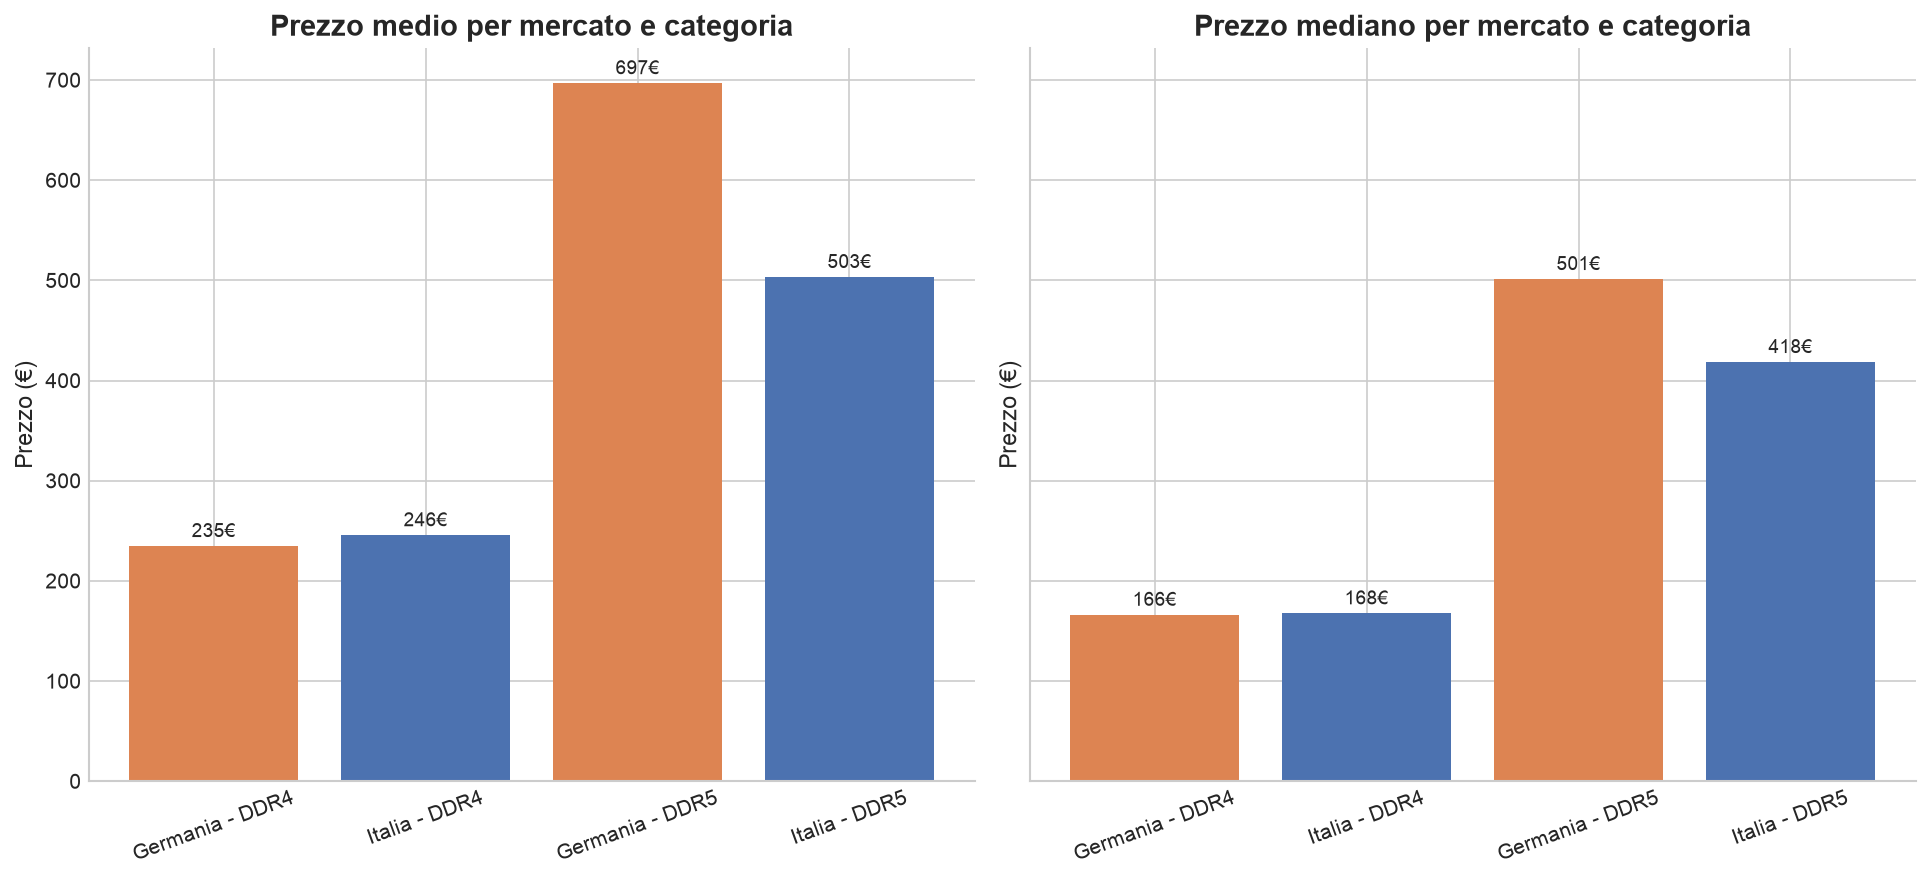

In [7]:
stats = df.groupby(['market_label', 'ram_category'])['rawPrice'].agg(['mean', 'median']).reset_index()
stats_long = stats.melt(id_vars=['market_label', 'ram_category'], value_vars=['mean', 'median'],
                         var_name='metric', value_name='price')
stats_long['metric'] = stats_long['metric'].map({'mean': 'Medio', 'median': 'Mediano'})
stats_long['label'] = stats_long['market_label'] + ' - ' + stats_long['ram_category']

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, metric in zip(axes, ['Medio', 'Mediano']):
    sub = stats_long[stats_long['metric'] == metric].sort_values(['ram_category', 'market_label'])
    colors = [COL_IT if 'Italia' in l else COL_DE for l in sub['label']]
    bars = ax.bar(sub['label'], sub['price'], color=colors)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:,.0f}€', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Prezzo {metric.lower()} per mercato e categoria', fontweight='bold')
    ax.set_ylabel('Prezzo (€)')
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/02_barchart_media_mediana.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Scatter "matched pairs": stesso prodotto, prezzo IT vs DE

Il campo `id` identifica lo stesso prodotto venduto su entrambi i mercati.
Qui isoliamo le 151 coppie IT+DE dello stesso modello per un confronto pulito, senza il rumore
di mix diversi di modelli tra i due mercati.

In [8]:
dup_ids = df[df['id'].duplicated(keep=False)].copy()
pairs = dup_ids.pivot_table(index='id', columns='market', values='rawPrice', aggfunc='first').dropna()
cat_map = dup_ids.groupby('id')['ram_category'].first()
pairs['ram_category'] = cat_map

print(f'Coppie matched trovate: {len(pairs)}')
pairs.head()

Coppie matched trovate: 151


market,DE,IT,ram_category
id,,,
4866786,110.90,113.90,DDR4
4885364,108.92,115.80,DDR4
4885703,207.90,213.90,DDR4
5047381,159.90,139.99,DDR4
5069026,59.90,69.99,DDR4


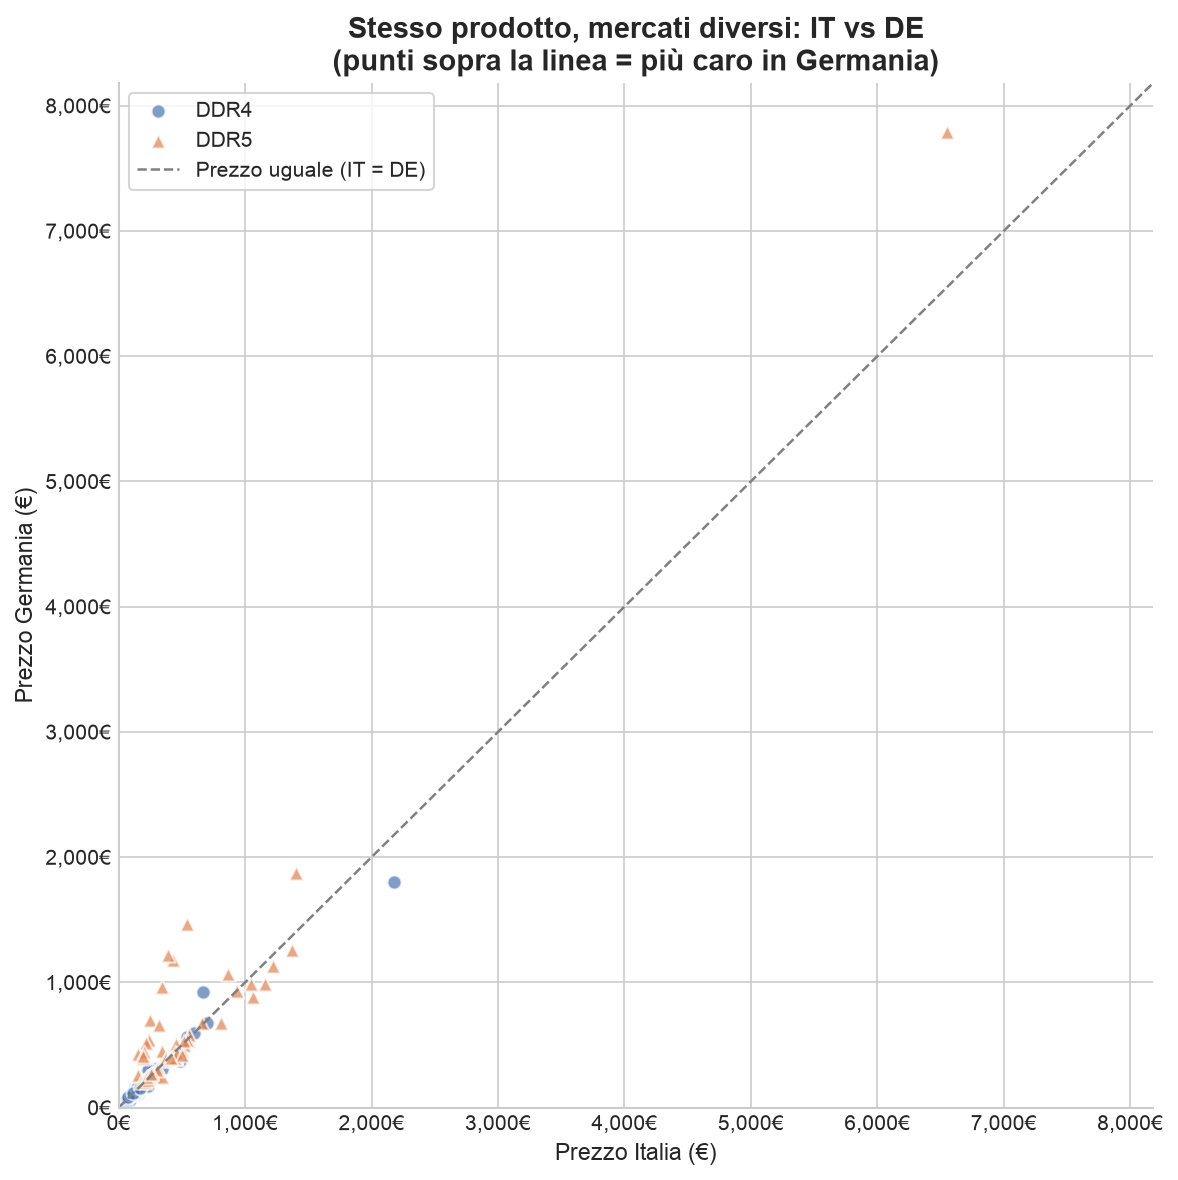

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
for cat, color, marker in [('DDR4', COL_IT, 'o'), ('DDR5', COL_DE, '^')]:
    sub = pairs[pairs['ram_category'] == cat]
    ax.scatter(sub['IT'], sub['DE'], label=cat, color=color, marker=marker, alpha=0.7, s=45, edgecolor='white')

max_val = max(pairs['IT'].max(), pairs['DE'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], color='grey', linestyle='--', linewidth=1.2, label='Prezzo uguale (IT = DE)')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel('Prezzo Italia (€)')
ax.set_ylabel('Prezzo Germania (€)')
ax.set_title('Stesso prodotto, mercati diversi: IT vs DE\n(punti sopra la linea = più caro in Germania)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}€'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}€'))
ax.legend(frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03_scatter_matched_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

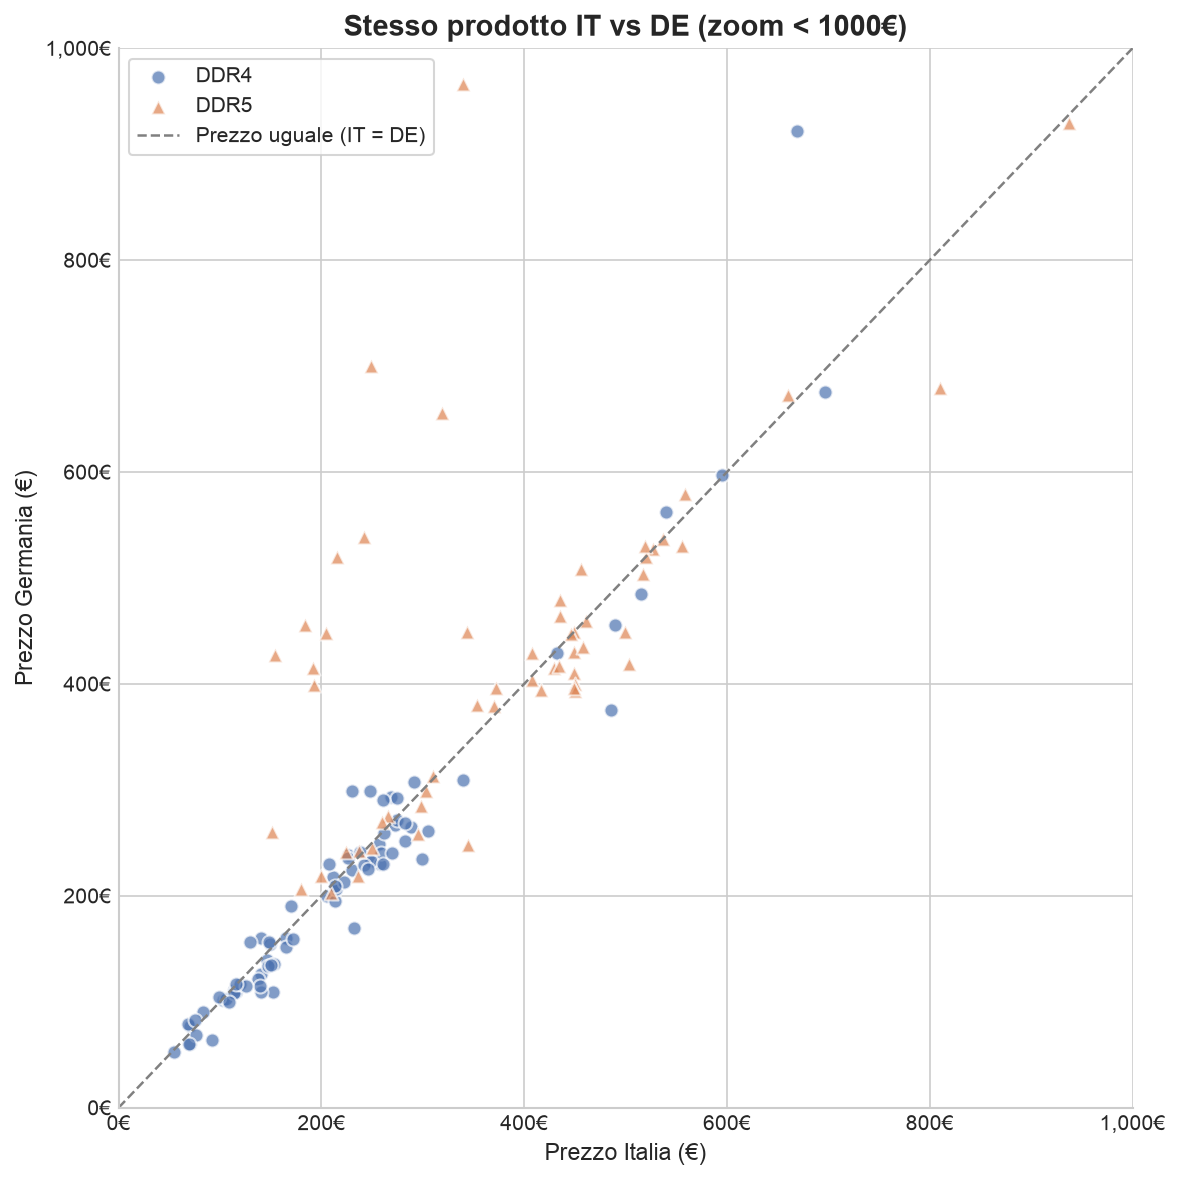

In [10]:
zoom_max = 1000

fig, ax = plt.subplots(figsize=(8, 8))
for cat, color, marker in [('DDR4', COL_IT, 'o'), ('DDR5', COL_DE, '^')]:
    sub = pairs[(pairs['ram_category'] == cat) & (pairs['IT'] <= zoom_max) & (pairs['DE'] <= zoom_max)]
    ax.scatter(sub['IT'], sub['DE'], label=cat, color=color, marker=marker, alpha=0.7, s=45, edgecolor='white')
ax.plot([0, zoom_max], [0, zoom_max], color='grey', linestyle='--', linewidth=1.2, label='Prezzo uguale (IT = DE)')
ax.set_xlim(0, zoom_max)
ax.set_ylim(0, zoom_max)
ax.set_xlabel('Prezzo Italia (€)')
ax.set_ylabel('Prezzo Germania (€)')
ax.set_title(f'Stesso prodotto IT vs DE (zoom < {zoom_max}€)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}€'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}€'))
ax.legend(frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03b_scatter_matched_pairs_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top 15 prodotti per differenza di prezzo assoluta (IT − DE)

**Nota:** troncare il titolo ai primi 45 caratteri puo' creare etichette duplicate quando due
varianti dello stesso prodotto differiscono solo dopo quel punto (es. CL diverso, SKU diverso).
Su un grafico a barre orizzontali, due etichette Y identiche fanno sovrapporre le barre
(e' successo con "G.Skill Trident Z5 Neo RGB 32GB Kit DDR5-6000" -828€ e -297€: la seconda
barra spariva dietro la prima). La funzione `make_label` tiene inizio + coda del titolo
(dove sta lo SKU) cosi' l'etichetta resta univoca, e le barre vengono disegnate su posizioni
numeriche (`np.arange`) invece che sul testo, cosi' anche in caso di residuo duplicato
non si sovrappongono mai.

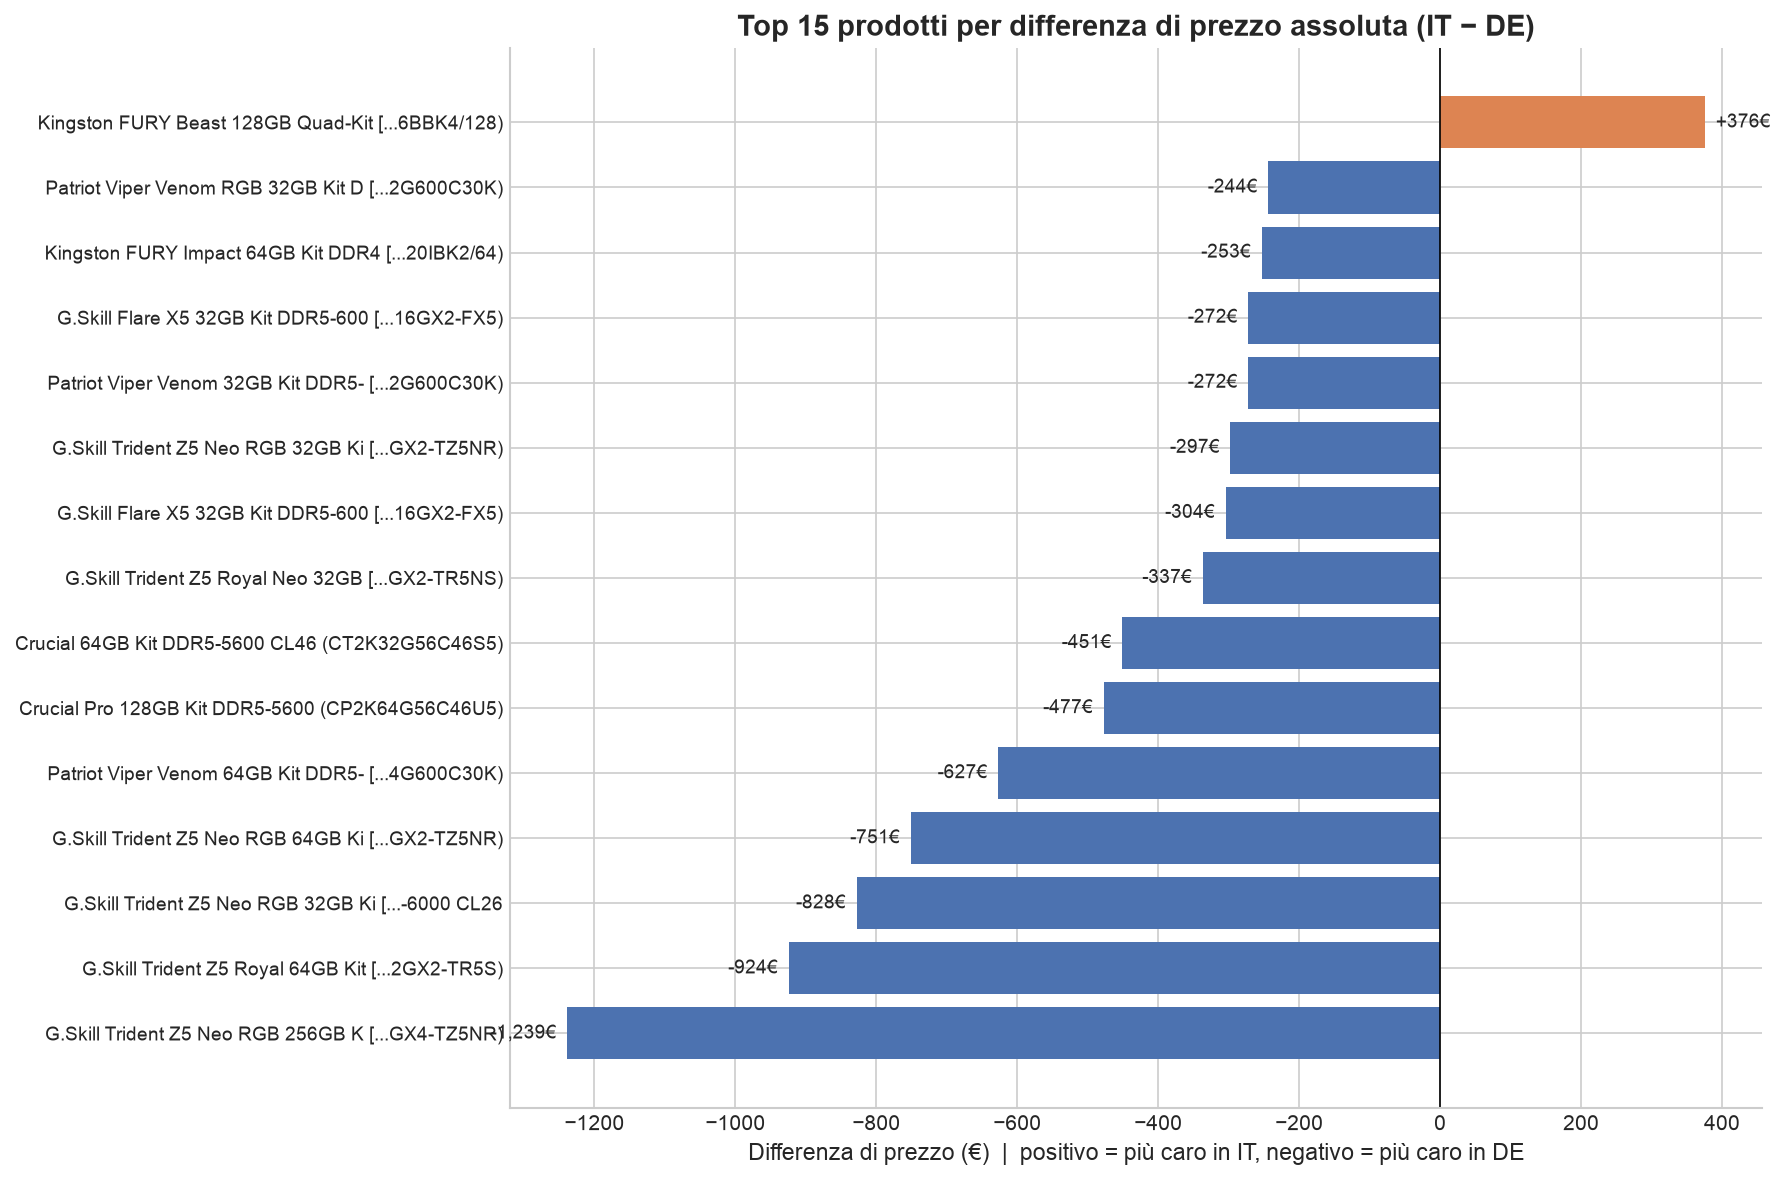

In [11]:
pairs['delta_eur'] = pairs['IT'] - pairs['DE']
pairs['delta_pct'] = (pairs['delta_eur'] / pairs['DE'] * 100)
titles = dup_ids.drop_duplicates('id').set_index('id')['title']
pairs['title'] = titles.reindex(pairs.index)

def make_label(t, maxlen=48):
    if len(t) <= maxlen:
        return t
    return t[:maxlen - 14].rstrip() + ' [...' + t[-10:]

pairs['title_short'] = pairs['title'].apply(make_label)

top15 = pairs.reindex(pairs['delta_eur'].abs().sort_values(ascending=False).index).head(15).sort_values('delta_eur')

y_pos = np.arange(len(top15))
fig, ax = plt.subplots(figsize=(12, 8))
colors = [COL_DE if v > 0 else COL_IT for v in top15['delta_eur']]
bars = ax.barh(y_pos, top15['delta_eur'], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15['title_short'], fontsize=9)
for bar in bars:
    w = bar.get_width()
    ax.text(w + (15 if w > 0 else -15), bar.get_y() + bar.get_height()/2,
            f'{w:+,.0f}€', ha='left' if w > 0 else 'right', va='center', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 prodotti per differenza di prezzo assoluta (IT − DE)', fontweight='bold')
ax.set_xlabel('Differenza di prezzo (€)  |  positivo = più caro in IT, negativo = più caro in DE')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/04_top15_delta_prezzo.png', dpi=150, bbox_inches='tight')
plt.show()

## Riepilogo file generati

Tutti i PNG sono salvati in `{OUT_DIR}`:
- `01_boxplot_prezzi_mercati.png`
- `01b_boxplot_prezzi_mercati_log.png`
- `02_barchart_media_mediana.png`
- `03_scatter_matched_pairs.png`
- `03b_scatter_matched_pairs_zoom.png`
- `04_top15_delta_prezzo.png`

## Ulteriori grafici

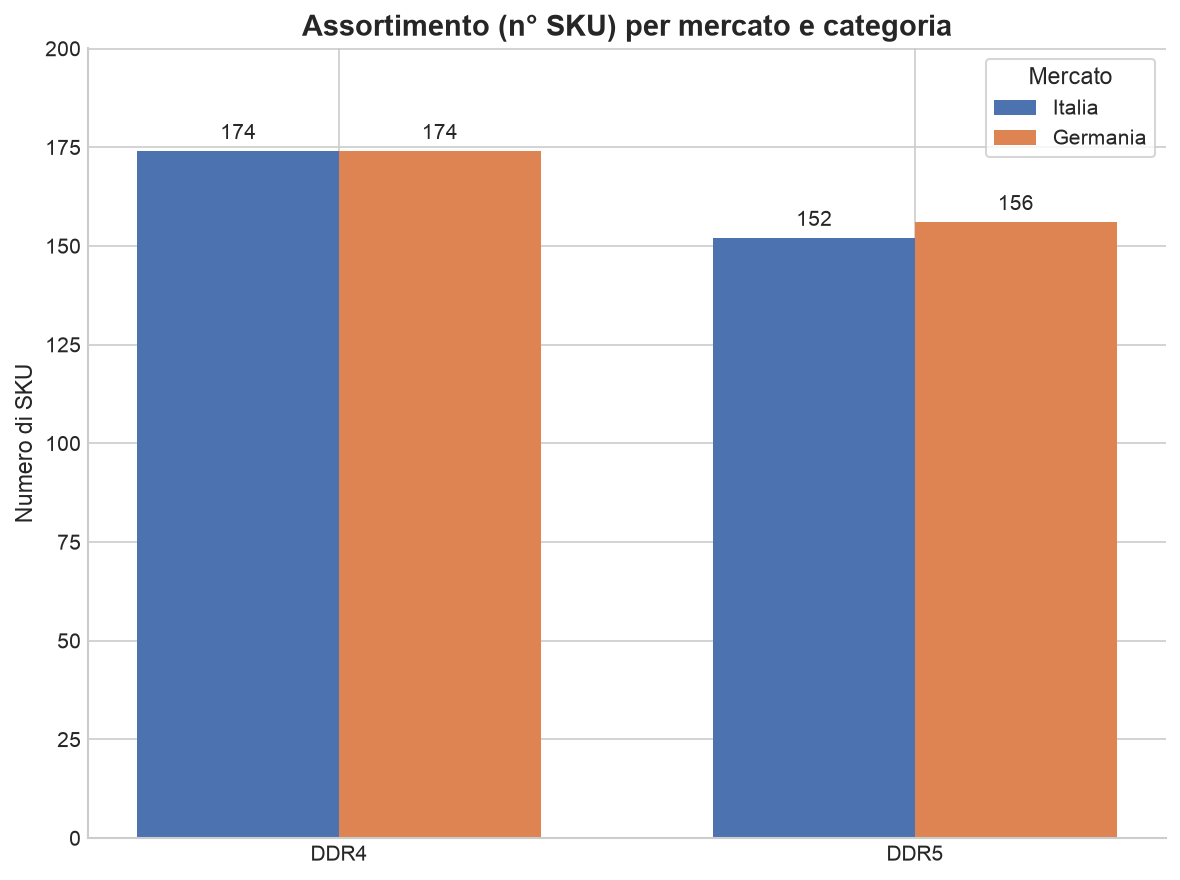

In [12]:
# Conteggio SKU per mercato x categoria
assortment = df.groupby(['market_label', 'ram_category']).size().reset_index(name='n_sku')

fig, ax = plt.subplots(figsize=(8, 6))
pivot = assortment.pivot(index='ram_category', columns='market_label', values='n_sku')
pivot = pivot[['Italia', 'Germania']]
x = np.arange(len(pivot.index))
width = 0.35

bars_it = ax.bar(x - width/2, pivot['Italia'], width, label='Italia', color=COL_IT)
bars_de = ax.bar(x + width/2, pivot['Germania'], width, label='Germania', color=COL_DE)

for bars in [bars_it, bars_de]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 2, f'{int(h)}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel('Numero di SKU')
ax.set_ylim(0, pivot.values.max() * 1.15)  # margine sopra per etichette + legenda
ax.set_title('Assortimento (n° SKU) per mercato e categoria', fontweight='bold')
ax.legend(title='Mercato', frameon=True, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/05_assortimento_sku.png', dpi=150, bbox_inches='tight')
plt.show()

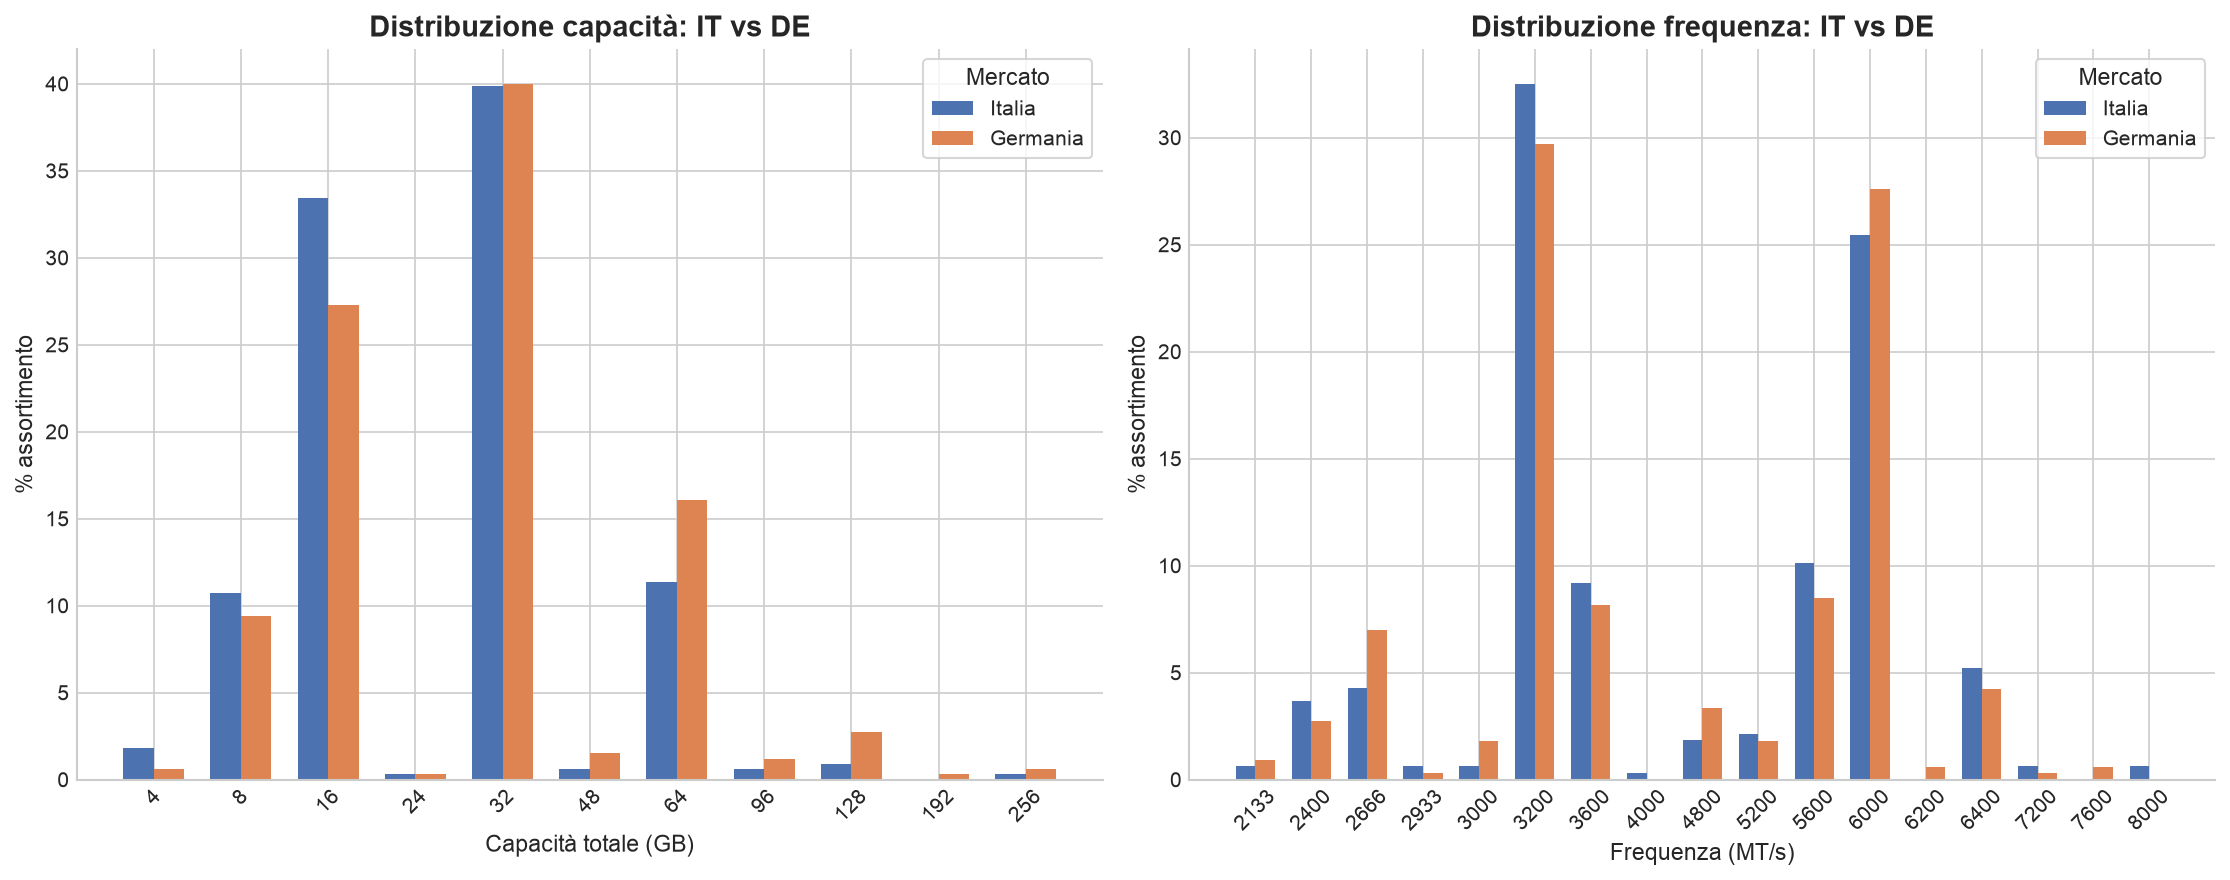

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Capacità totale (GB) ---
cap_share = (df.groupby(['market_label', 'total_capacity_gb']).size()
             / df.groupby('market_label').size() * 100).rename('pct').reset_index()
cap_pivot = cap_share.pivot(index='total_capacity_gb', columns='market_label', values='pct').fillna(0)
cap_pivot = cap_pivot[['Italia', 'Germania']]

x = np.arange(len(cap_pivot.index))
width = 0.35
axes[0].bar(x - width/2, cap_pivot['Italia'], width, label='Italia', color=COL_IT)
axes[0].bar(x + width/2, cap_pivot['Germania'], width, label='Germania', color=COL_DE)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{int(c)}' for c in cap_pivot.index], rotation=45)
axes[0].set_xlabel('Capacità totale (GB)')
axes[0].set_ylabel('% assortimento')
axes[0].set_title('Distribuzione capacità: IT vs DE', fontweight='bold')
axes[0].legend(title='Mercato', frameon=True)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Frequenza (MT/s) ---
freq_share = (df.groupby(['market_label', 'frequency_mts']).size()
              / df.groupby('market_label').size() * 100).rename('pct').reset_index()
freq_pivot = freq_share.pivot(index='frequency_mts', columns='market_label', values='pct').fillna(0)
freq_pivot = freq_pivot[['Italia', 'Germania']]

x = np.arange(len(freq_pivot.index))
axes[1].bar(x - width/2, freq_pivot['Italia'], width, label='Italia', color=COL_IT)
axes[1].bar(x + width/2, freq_pivot['Germania'], width, label='Germania', color=COL_DE)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{int(f)}' for f in freq_pivot.index], rotation=45)
axes[1].set_xlabel('Frequenza (MT/s)')
axes[1].set_ylabel('% assortimento')
axes[1].set_title('Distribuzione frequenza: IT vs DE', fontweight='bold')
axes[1].legend(title='Mercato', frameon=True)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/06_capacita_frequenza_mercati.png', dpi=150, bbox_inches='tight')
plt.show()

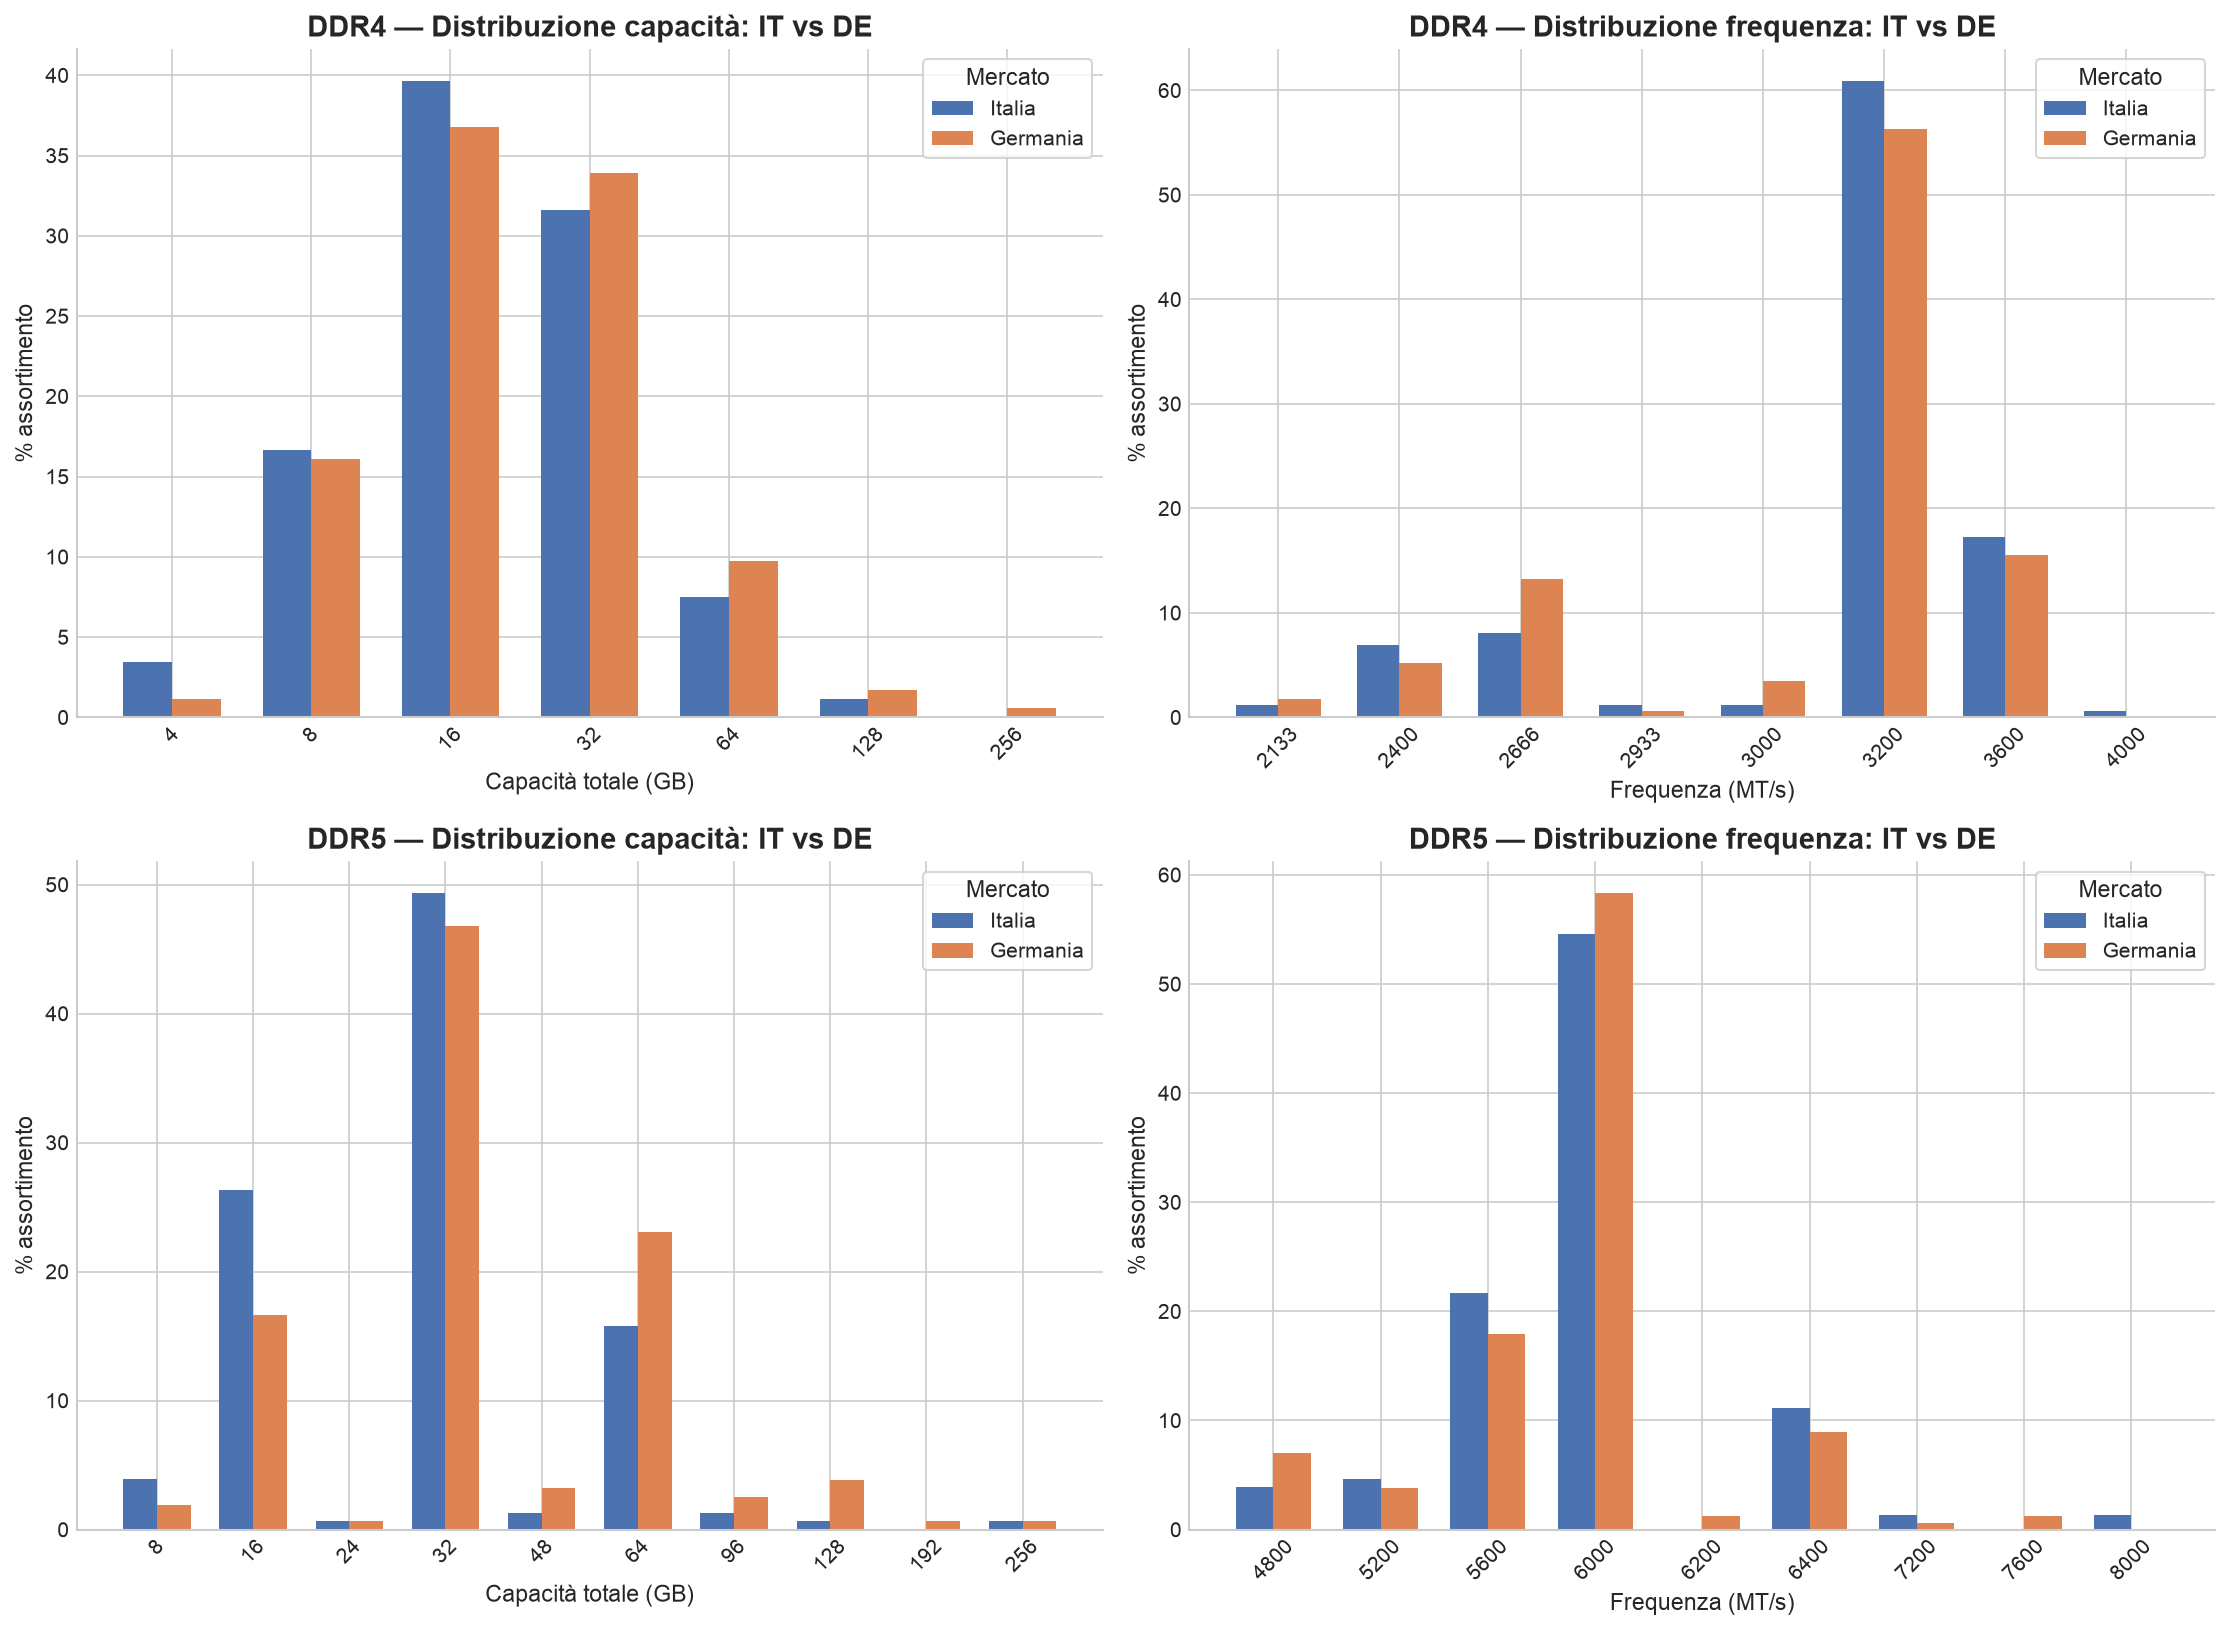

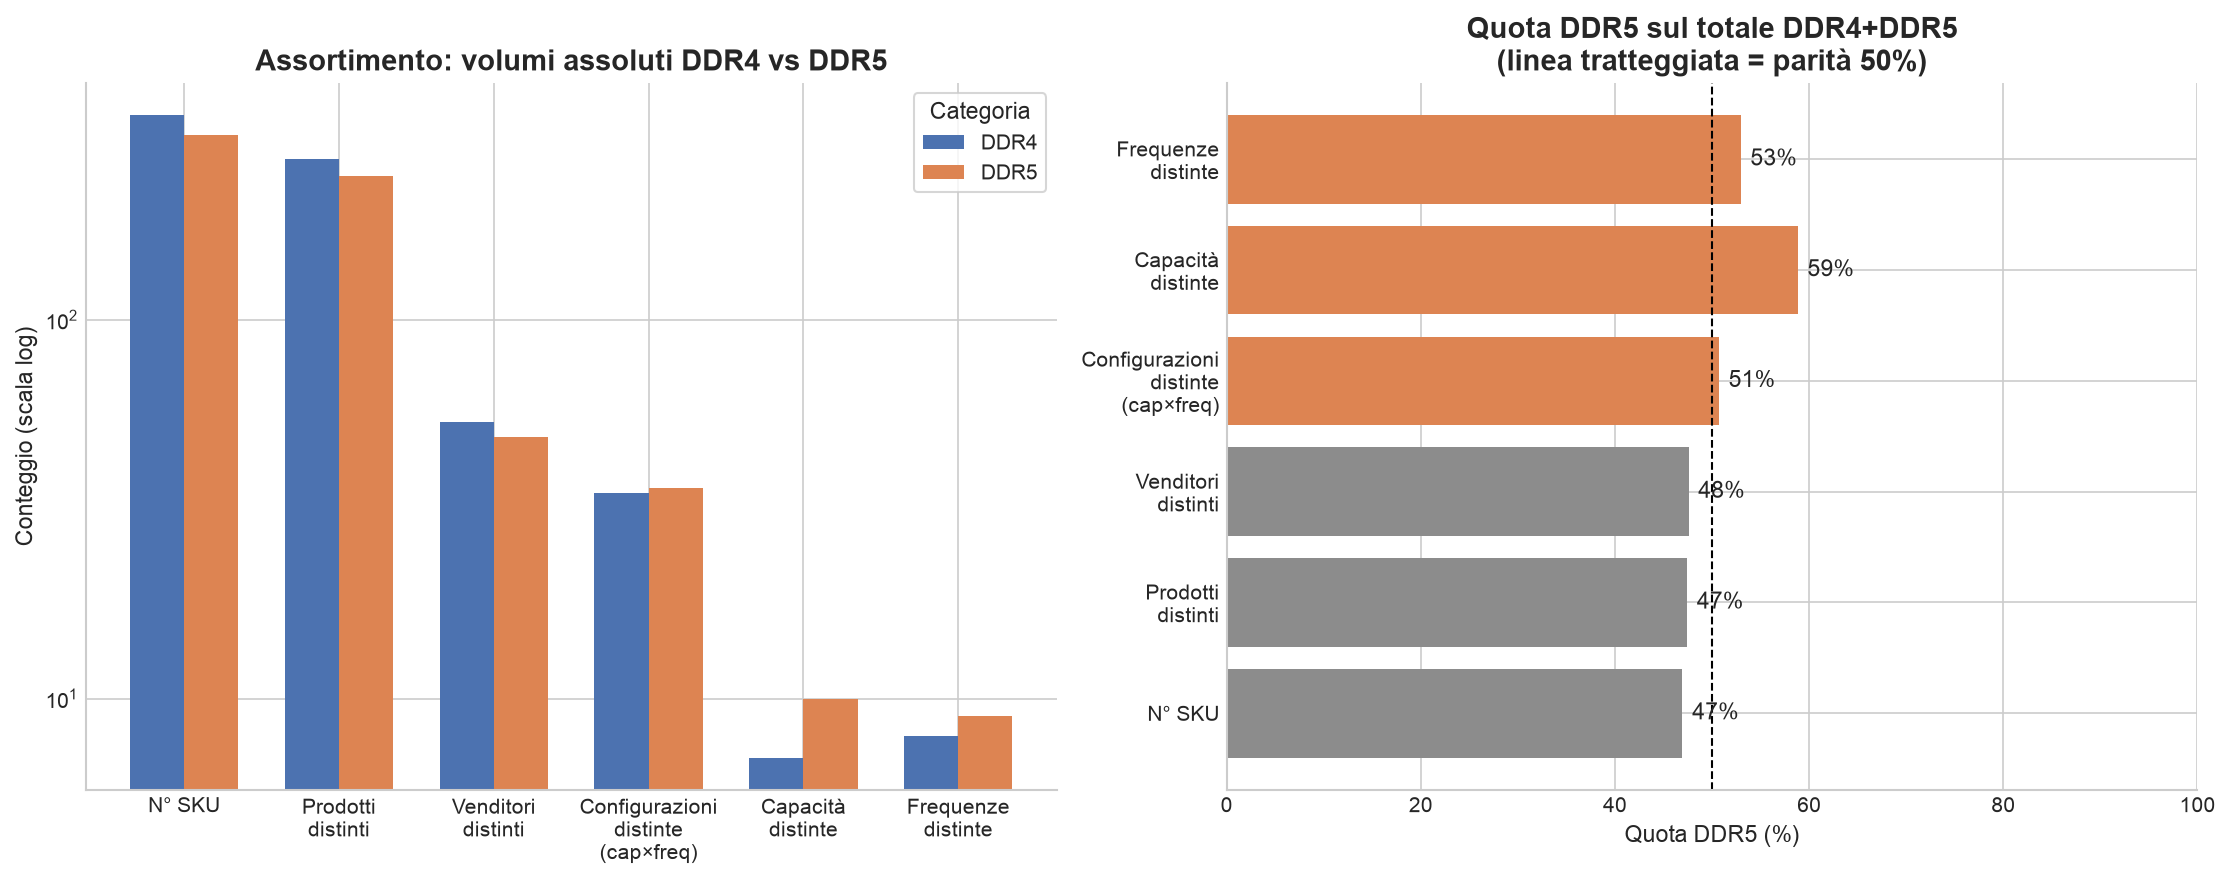

  ram_category  n_sku  n_prodotti_distinti  n_venditori_distinti  \
0         DDR4    348                  266                    54   
1         DDR5    308                  240                    49   

   n_capacita_distinte  n_frequenze_distinte  n_configurazioni_distinte  
0                    7                     8                         35  
1                   10                     9                         36  


In [15]:
# ==========================================================
# 7. Capacità/frequenza per mercato E categoria (fix Q3)
# ==========================================================
# La versione precedente (cella 21, file 06_...) mischia DDR4 e DDR5:
# essendo range molto diversi, il confronto tra mercati risulta poco
# leggibile. Qui separiamo i due grafici per categoria.

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for row, cat in enumerate(['DDR4', 'DDR5']):
    sub = df[df['ram_category'] == cat]

    # --- Capacità totale (GB) ---
    cap_share = (sub.groupby(['market_label', 'total_capacity_gb']).size()
                 / sub.groupby('market_label').size() * 100).rename('pct').reset_index()
    cap_pivot = cap_share.pivot(index='total_capacity_gb', columns='market_label', values='pct').fillna(0)
    cap_pivot = cap_pivot[['Italia', 'Germania']]

    x = np.arange(len(cap_pivot.index))
    width = 0.35
    ax = axes[row, 0]
    ax.bar(x - width/2, cap_pivot['Italia'], width, label='Italia', color=COL_IT)
    ax.bar(x + width/2, cap_pivot['Germania'], width, label='Germania', color=COL_DE)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(c)}' for c in cap_pivot.index], rotation=45)
    ax.set_xlabel('Capacità totale (GB)')
    ax.set_ylabel('% assortimento')
    ax.set_title(f'{cat} — Distribuzione capacità: IT vs DE', fontweight='bold')
    ax.legend(title='Mercato', frameon=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- Frequenza (MT/s) ---
    freq_share = (sub.groupby(['market_label', 'frequency_mts']).size()
                  / sub.groupby('market_label').size() * 100).rename('pct').reset_index()
    freq_pivot = freq_share.pivot(index='frequency_mts', columns='market_label', values='pct').fillna(0)
    freq_pivot = freq_pivot[['Italia', 'Germania']]

    x = np.arange(len(freq_pivot.index))
    ax = axes[row, 1]
    ax.bar(x - width/2, freq_pivot['Italia'], width, label='Italia', color=COL_IT)
    ax.bar(x + width/2, freq_pivot['Germania'], width, label='Germania', color=COL_DE)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(f)}' for f in freq_pivot.index], rotation=45)
    ax.set_xlabel('Frequenza (MT/s)')
    ax.set_ylabel('% assortimento')
    ax.set_title(f'{cat} — Distribuzione frequenza: IT vs DE', fontweight='bold')
    ax.legend(title='Mercato', frameon=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/07_capacita_frequenza_per_categoria.png', dpi=150, bbox_inches='tight')
plt.show()


# ==========================================================
# 8. Maturità dell'offerta DDR5 vs dominanza DDR4 (risponde alla Q4)
# ==========================================================
# La Q2/grafico 05 misura solo il NUMERO di SKU per categoria.
# La Q4 chiede se la VARIETA' dell'offerta DDR5 è già matura:
# qui confrontiamo, per categoria, il numero di SKU con il numero
# di configurazioni distinte (capacità × frequenza), di prodotti
# distinti (title) e di venditori distinti (shopName).

variety = df.groupby('ram_category').agg(
    n_sku=('id', 'size'),
    n_prodotti_distinti=('title', 'nunique'),
    n_venditori_distinti=('shopName', 'nunique'),
    n_capacita_distinte=('total_capacity_gb', 'nunique'),
    n_frequenze_distinte=('frequency_mts', 'nunique'),
).reset_index()

# configurazioni distinte capacità x frequenza
combo = (df.groupby('ram_category')
           .apply(lambda g: g[['total_capacity_gb', 'frequency_mts']].drop_duplicates().shape[0])
           .rename('n_configurazioni_distinte').reset_index())
variety = variety.merge(combo, on='ram_category')

metrics = ['n_sku', 'n_prodotti_distinti', 'n_venditori_distinti',
           'n_configurazioni_distinte', 'n_capacita_distinte', 'n_frequenze_distinte']
labels = ['N° SKU', 'Prodotti\ndistinti', 'Venditori\ndistinti',
          'Configurazioni\ndistinte\n(cap×freq)', 'Capacità\ndistinte', 'Frequenze\ndistinte']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Pannello sinistro: volumi assoluti (scala log per confrontare grandezze diverse) ---
x = np.arange(len(metrics))
width = 0.35
ddr4_vals = variety.set_index('ram_category').loc['DDR4', metrics]
ddr5_vals = variety.set_index('ram_category').loc['DDR5', metrics]

axes[0].bar(x - width/2, ddr4_vals, width, label='DDR4', color='#4C72B0')
axes[0].bar(x + width/2, ddr5_vals, width, label='DDR5', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_yscale('log')
axes[0].set_ylabel('Conteggio (scala log)')
axes[0].set_title('Assortimento: volumi assoluti DDR4 vs DDR5', fontweight='bold')
axes[0].legend(title='Categoria', frameon=True)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Pannello destro: quota % di DDR5 su ciascuna metrica ---
pct_ddr5 = (ddr5_vals / (ddr4_vals + ddr5_vals) * 100)
colors = ['#DD8452' if v >= 50 else '#8c8c8c' for v in pct_ddr5]
axes[1].barh(labels, pct_ddr5, color=colors)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Quota DDR5 (%)')
axes[1].set_xlim(0, 100)
axes[1].set_title('Quota DDR5 sul totale DDR4+DDR5\n(linea tratteggiata = parità 50%)', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate(pct_ddr5):
    axes[1].text(v + 1, i, f'{v:.0f}%', va='center')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/08_maturita_assortimento_ddr5.png', dpi=150, bbox_inches='tight')
plt.show()

print(variety)